In [2]:
#1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [32]:
#2. Load dataset
df = pd.read_csv("C:/Users/dell/Desktop/Space_Missions Dataset.csv")
df

,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission,Country,DateTime,Year,Launch_Site,Count,Month
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,USA,2020-08-07 05:12:00+00:00,2020,"LC-39A, Kennedy Space Center, Florida",1,Aug
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,2020-08-06 04:01:00+00:00,2020,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",1,Aug
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,USA,2020-08-04 23:57:00+00:00,2020,"Pad A, Boca Chica, Texas",1,Aug
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,Kazakhstan,2020-07-30 21:25:00+00:00,2020,"Site 200/39, Baikonur Cosmodrome",1,Jul
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success,USA,2020-07-30 11:50:00+00:00,2020,"SLC-41, Cape Canaveral AFS, Florida",1,Jul
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure,USA,1958-02-05 07:33:00+00:00,1958,"LC-18A, Cape Canaveral AFS, Florida",1,Feb
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success,USA,1958-02-01 03:48:00+00:00,1958,"LC-26A, Cape Canaveral AFS, Florida",1,Feb
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure,USA,1957-12-06 16:44:00+00:00,1957,"LC-18A, Cape Canaveral AFS, Florida",1,Dec
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success,Kazakhstan,1957-11-03 02:30:00+00:00,1957,"Site 1/5, Baikonur Cosmodrome",1,Nov


In [33]:
#3. Clean and preprocess the data
# Drop irrelevant or redundant columns
df_cleaned = df.drop(columns=['Datum', 'Detail', 'DateTime'])

In [34]:
# Fill missing 'Rocket' values (assumed cost) with mean
df_cleaned['Rocket'] = df_cleaned['Rocket'].fillna(df_cleaned['Rocket'].mean(numeric_only=True))
df_cleaned

,Company Name,Location,Status Rocket,Rocket,Status Mission,Country,Year,Launch_Site,Count,Month
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",StatusActive,50.000000,Success,USA,2020,"LC-39A, Kennedy Space Center, Florida",1,Aug
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",StatusActive,29.750000,Success,China,2020,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",1,Aug
2,SpaceX,"Pad A, Boca Chica, Texas, USA",StatusActive,153.792199,Success,USA,2020,"Pad A, Boca Chica, Texas",1,Aug
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",StatusActive,65.000000,Success,Kazakhstan,2020,"Site 200/39, Baikonur Cosmodrome",1,Jul
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",StatusActive,145.000000,Success,USA,2020,"SLC-41, Cape Canaveral AFS, Florida",1,Jul
...,...,...,...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",StatusRetired,153.792199,Failure,USA,1958,"LC-18A, Cape Canaveral AFS, Florida",1,Feb
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",StatusRetired,153.792199,Success,USA,1958,"LC-26A, Cape Canaveral AFS, Florida",1,Feb
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",StatusRetired,153.792199,Failure,USA,1957,"LC-18A, Cape Canaveral AFS, Florida",1,Dec
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",StatusRetired,153.792199,Success,Kazakhstan,1957,"Site 1/5, Baikonur Cosmodrome",1,Nov


APPLYING FEATURE ENGINEERING

In [36]:
#Calculate Success Rate 
success_count = df[df['Status Mission'].str.lower() == 'success'].shape[0]
total_count = df.shape[0]
success_rate = (success_count / total_count) * 100
print(f"Success Rate: {success_rate:.2f}%")

Success Rate: 89.71%


In [37]:
# Encode categorical columns
label_encoders = {}
categorical_cols = ['Company Name', 'Location', 'Status Rocket', 'Country', 'Launch_Site', 'Month']
for col in categorical_cols:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le

In [38]:
# Encode target: 1 for Success, 0 for anything else
df_cleaned['Status Mission'] = df_cleaned['Status Mission'].apply(lambda x: 1 if x == 'Success' else 0)

In [39]:
#4. Prepare features and target
X = df_cleaned.drop('Status Mission', axis=1)
y = df_cleaned['Status Mission']

In [40]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
#5. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

RANDOM FOREST CLASSIFIER MODEL:

In [42]:
#Train RandomForest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#Evaluate the model
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100),"%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 89 %

Confusion Matrix:
 [[ 23  64]
 [ 27 751]]

Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.26      0.34        87
           1       0.92      0.97      0.94       778

    accuracy                           0.89       865
   macro avg       0.69      0.61      0.64       865
weighted avg       0.88      0.89      0.88       865



LOGISTIC REGRESSION MODEL:

In [13]:
#Import required Libraries
from sklearn.linear_model import LogisticRegression

# Train logistic regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = log_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100),"%")
print("\nConfusion Matrix:\n",confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n",classification_report(y_test, y_pred))


Accuracy: 90 %

Confusion Matrix:
 [[  0  87]
 [  0 778]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.90      1.00      0.95       778

    accuracy                           0.90       865
   macro avg       0.45      0.50      0.47       865
weighted avg       0.81      0.90      0.85       865



C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

K-NEAREST NEIGHBORS(KNN) CLASSIFIER MODEL:

In [14]:
#Import required libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Initialize and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)

#Make predictions
y_pred_knn = knn_model.predict(X_test)

#Evaluate the model
print("Accuracy:", round(accuracy_score(y_test, y_pred_knn)*100),"%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))


Accuracy: 90 %

Confusion Matrix:
 [[ 10  77]
 [ 10 768]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.11      0.19        87
           1       0.91      0.99      0.95       778

    accuracy                           0.90       865
   macro avg       0.70      0.55      0.57       865
weighted avg       0.87      0.90      0.87       865



SUPPORT VECTOR MACHINE(SVM) CLASSIFIER MODEL:

In [15]:
#Import necessary libraries
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Initialize and train the SVM model
svm_model = SVC(kernel='rbf', probability=True, random_state=42)  # RBF is default, works well in most cases
svm_model.fit(X_train, y_train)

#Predict on test data
y_pred_svm = svm_model.predict(X_test)

#Evaluate the SVM model
print("Accuracy:", round(accuracy_score(y_test, y_pred_svm)*100),"%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


Accuracy: 90 %

Confusion Matrix:
 [[  2  85]
 [  0 778]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.02      0.04        87
           1       0.90      1.00      0.95       778

    accuracy                           0.90       865
   macro avg       0.95      0.51      0.50       865
weighted avg       0.91      0.90      0.86       865



MODEL COMPARISON TABLE

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
#Initialize models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='rbf', probability=True, random_state=42)
}

#Dictionary to store results
comparison_results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": [],
    "ROC AUC": []
}

#Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]

    comparison_results["Model"].append(name)
    comparison_results["Accuracy"].append(round(accuracy_score(y_test, y_pred)*100))
    comparison_results["Precision"].append(precision_score(y_test, y_pred)*100)
    comparison_results["Recall"].append(recall_score(y_test, y_pred)*100)
    comparison_results["F1 Score"].append(f1_score(y_test, y_pred)*100)
    comparison_results["ROC AUC"].append(roc_auc_score(y_test, y_probs)*100)

#Convert to DataFrame and sort by F1 Score
comparison_df = pd.DataFrame(comparison_results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

#Display the final comparison table
print("Model Comparison Table:\n")
display(comparison_df)


Model Comparison Table:



,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Support Vector Machine,90,90.150637,100.000000,94.820232,66.967320
1,Logistic Regression,90,89.942197,100.000000,94.704808,65.665721
2,K-Nearest Neighbors,90,90.887574,98.714653,94.639556,69.420560
3,Random Forest,89,92.147239,96.529563,94.287508,74.312265


Random Forest seems to be the best overall model given the combination of its performance across all metrics.

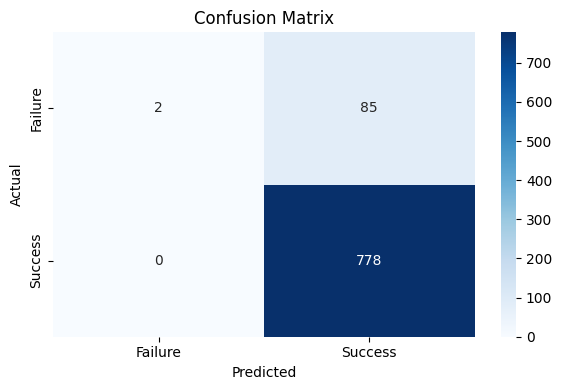

In [44]:
#Visualization for our best fit "Random Forest classifier" Model
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Failure', 'Success'], yticklabels=['Failure', 'Success'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()